In [18]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")

print(df.shape)

df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [20]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Revenue"].sum()


np.float64(9747747.934)

In [21]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

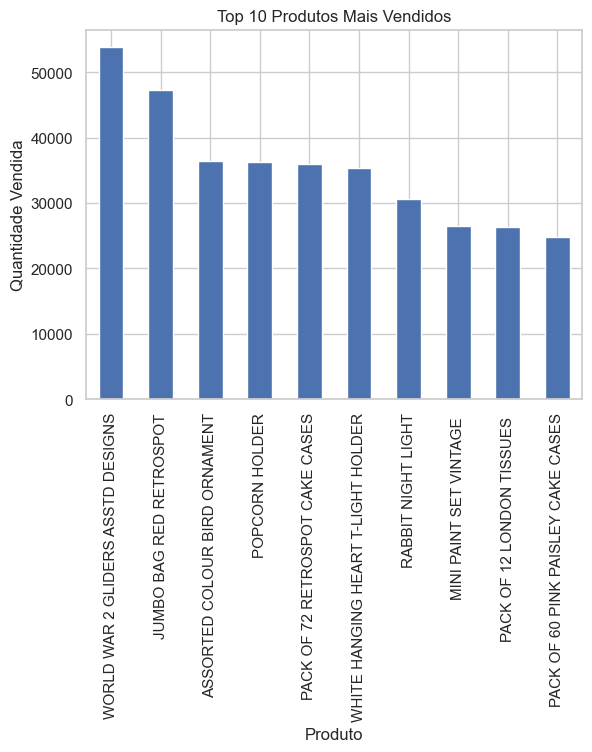

In [22]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")

plt.title("Top 10 Produtos Mais Vendidos")
plt.xlabel("Produto")
plt.ylabel("Quantidade Vendida")

plt.show()

C:\Users\oliveira.kaique1\AppData\Local\Temp\ipykernel_23460\4094486571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


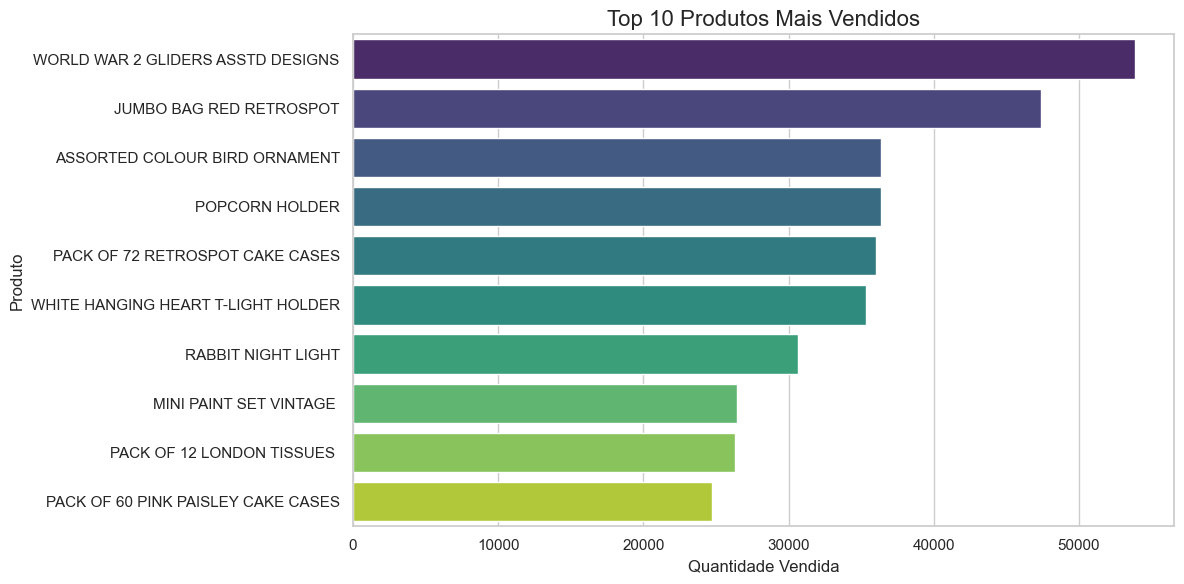

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Produtos Mais Vendidos", fontsize=16)
plt.xlabel("Quantidade Vendida")
plt.ylabel("Produto")

plt.tight_layout()
plt.show()

### Análise de Produtos Mais Vendidos

O gráfico apresenta os 10 produtos com maior quantidade vendida no dataset.

Essa análise permite identificar quais itens possuem maior demanda entre os clientes, ajudando a entender padrões de consumo e possíveis oportunidades de estoque ou marketing.

Produtos com maior volume de vendas tendem a representar itens populares ou de compra recorrente.

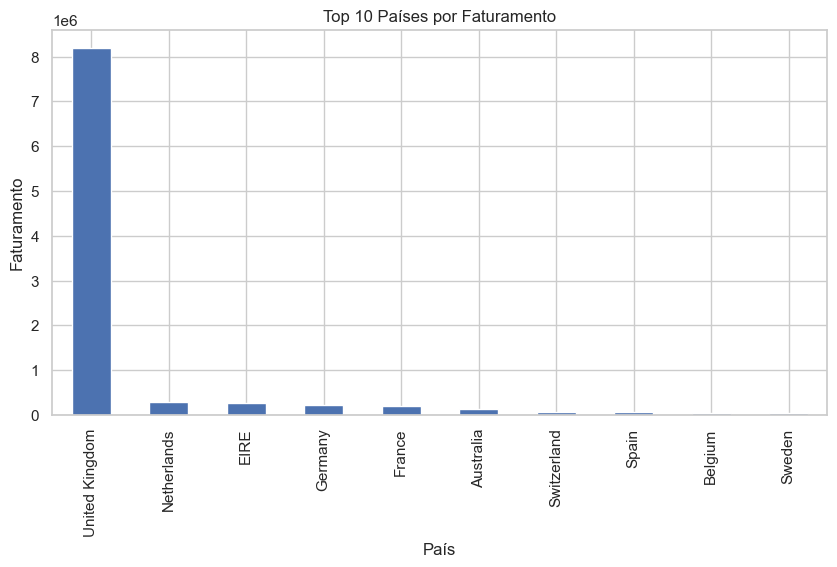

C:\Users\oliveira.kaique1\AppData\Local\Temp\ipykernel_23460\1108931655.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


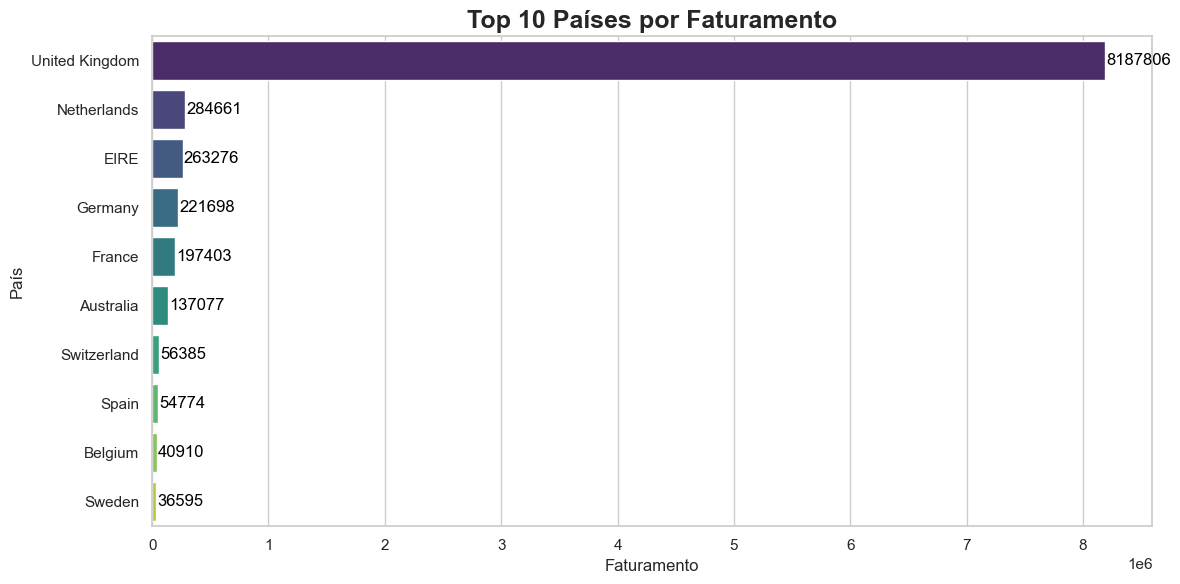

In [24]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Países por Faturamento")
plt.xlabel("País")
plt.ylabel("Faturamento")

plt.show()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="viridis"
)

plt.title("Top 10 Países por Faturamento", fontsize=18, weight="bold")
plt.xlabel("Faturamento", fontsize=12)
plt.ylabel("País", fontsize=12)

for i, v in enumerate(top_countries.values):
    ax.text(v + 10000, i, f"{int(v)}", color="black", va="center")

plt.tight_layout()
plt.show()

### Análise de Faturamento por País

Este gráfico mostra os países responsáveis pelo maior faturamento da loja.

A análise permite identificar quais mercados internacionais são mais relevantes para o negócio.

Com essas informações, a empresa pode direcionar estratégias de marketing, logística e expansão para regiões com maior potencial de vendas.

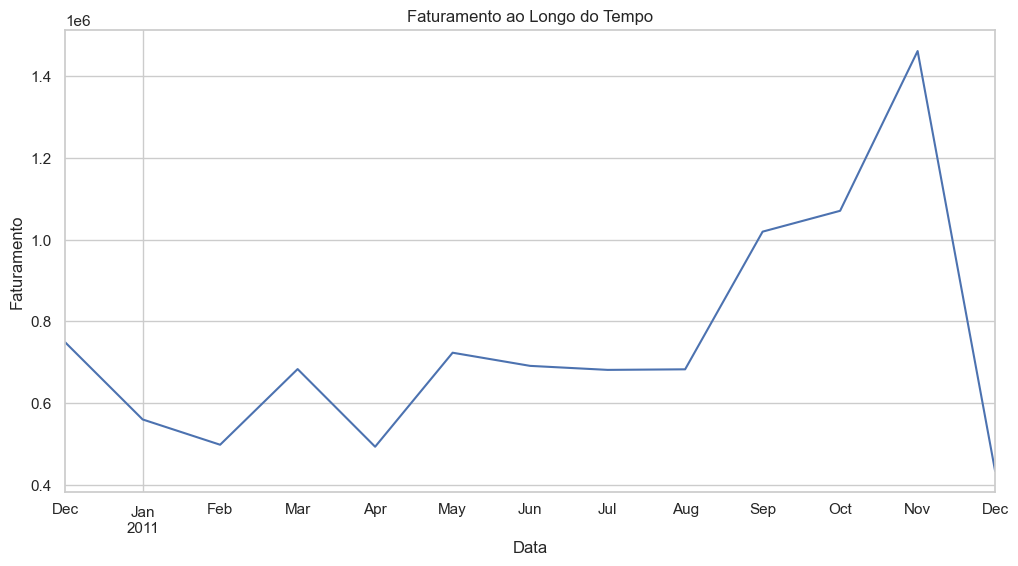

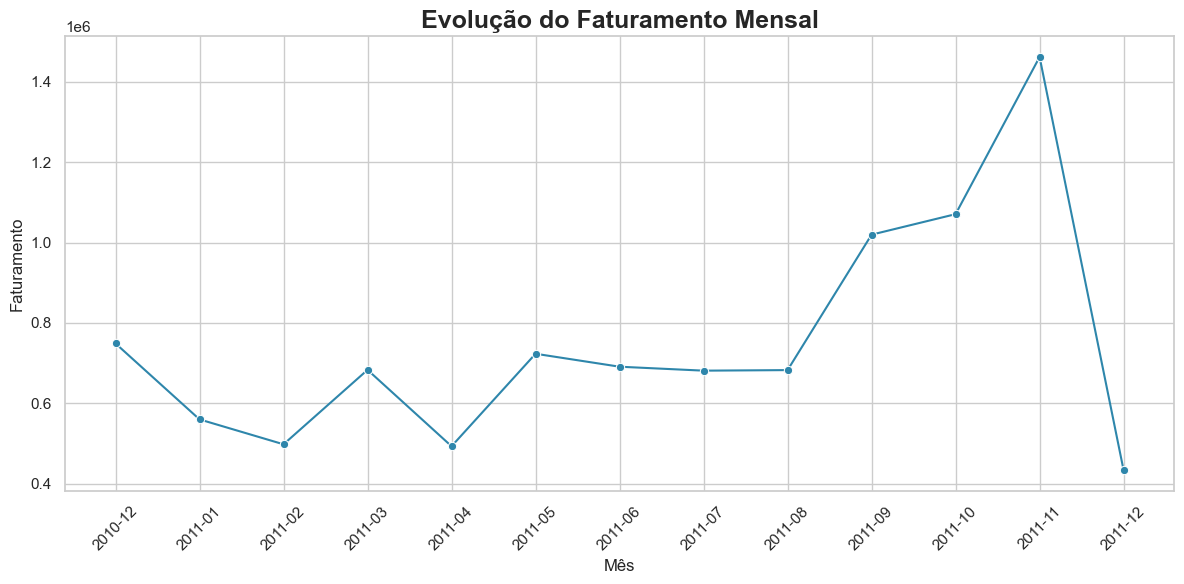

In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

sales_over_time = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()

sales_over_time.plot(figsize=(12,6))

plt.title("Faturamento ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Faturamento")

plt.show()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=sales_over_time.index.astype(str),
    y=sales_over_time.values,
    marker="o",
    color="#2E86AB"
)

plt.title("Evolução do Faturamento Mensal", fontsize=18, weight="bold")
plt.xlabel("Mês")
plt.ylabel("Faturamento")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Evolução do Faturamento ao Longo do Tempo

Este gráfico apresenta a evolução do faturamento mensal ao longo do período analisado.

A visualização permite identificar tendências de crescimento, queda nas vendas ou possíveis sazonalidades no comportamento dos consumidores.

Esse tipo de análise é importante para planejamento estratégico e previsão de vendas.

In [26]:
top_revenue_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

top_revenue_products

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

C:\Users\oliveira.kaique1\AppData\Local\Temp\ipykernel_23460\1845375397.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


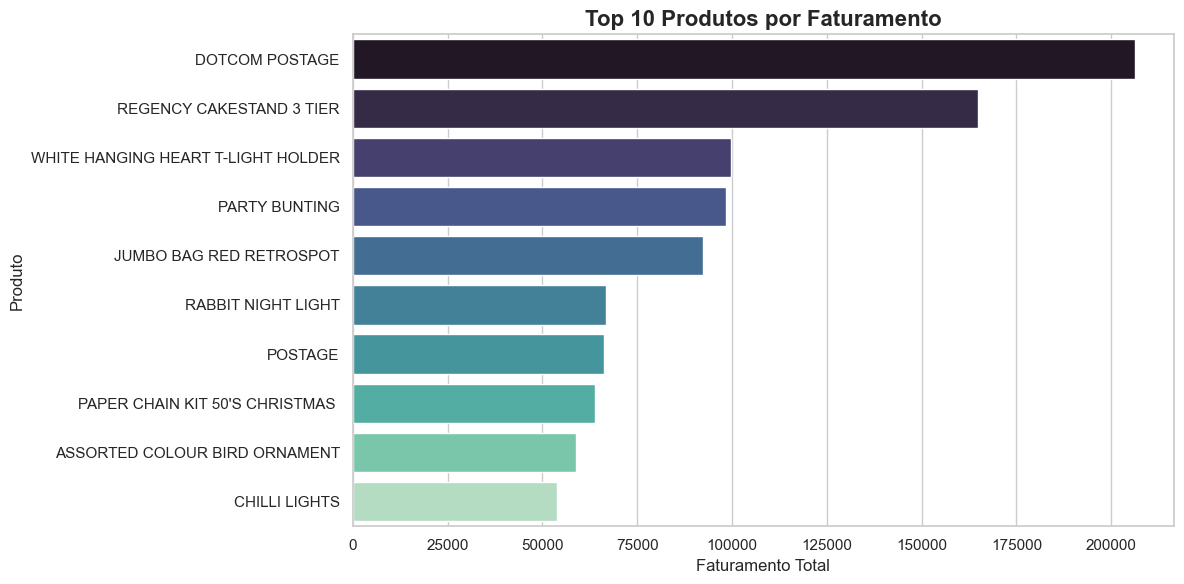

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index,
    palette="mako"
)

plt.title("Top 10 Produtos por Faturamento", fontsize=16, weight="bold")
plt.xlabel("Faturamento Total")
plt.ylabel("Produto")

plt.tight_layout()
plt.show()

### Análise de Produtos por Faturamento

Nesta análise, foram identificados os produtos com maior faturamento total, considerando o impacto financeiro de cada item.

Diferente da análise por quantidade, essa abordagem permite identificar quais produtos geram maior valor para o negócio, auxiliando na tomada de decisões estratégicas como priorização de estoque e campanhas promocionais.

In [28]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

top_customers

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

C:\Users\oliveira.kaique1\AppData\Local\Temp\ipykernel_23460\202467595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


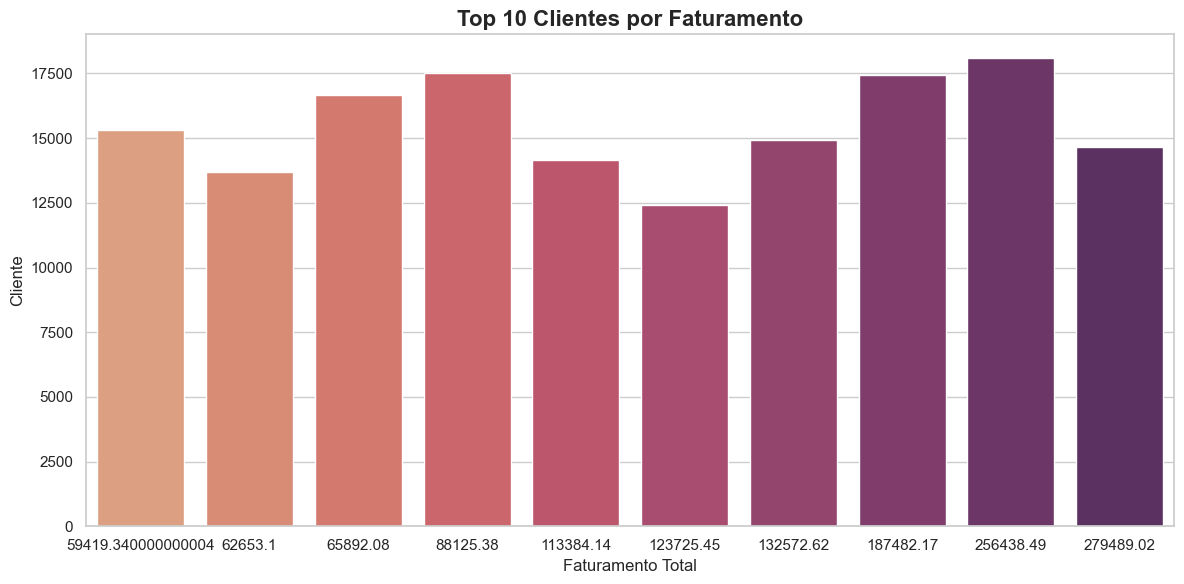

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette="flare"
)

plt.title("Top 10 Clientes por Faturamento", fontsize=16, weight="bold")
plt.xlabel("Faturamento Total")
plt.ylabel("Cliente")

plt.tight_layout()
plt.show()

C:\Users\oliveira.kaique1\AppData\Local\Temp\ipykernel_23460\2229687945.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


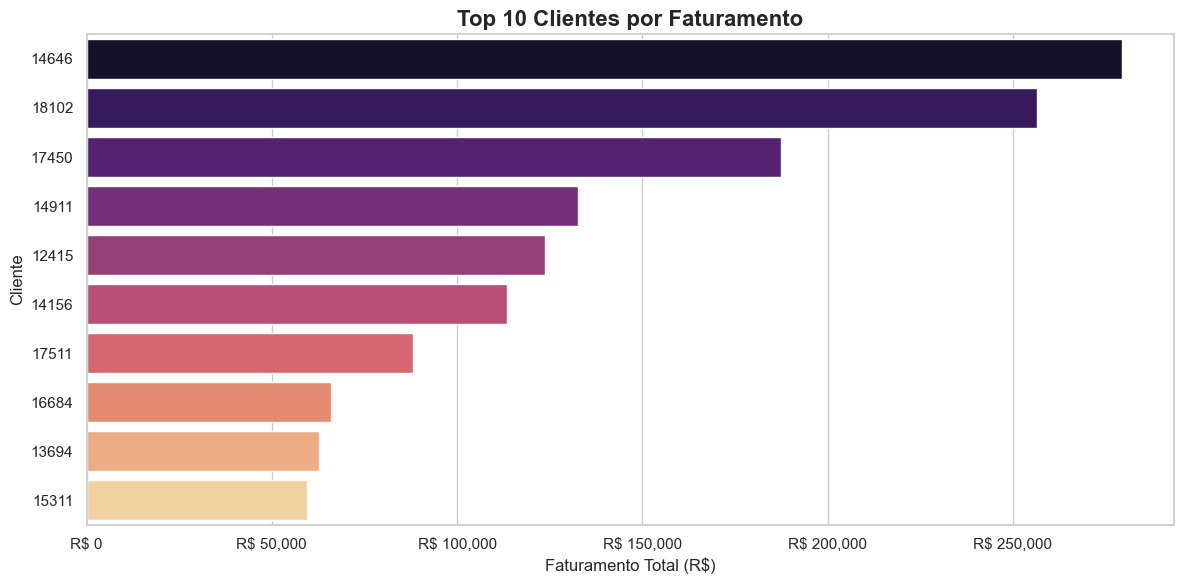

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# garantir ordem correta
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(int).astype(str),
    palette="magma"
)

plt.title("Top 10 Clientes por Faturamento", fontsize=16, weight="bold")
plt.xlabel("Faturamento Total (R$)")
plt.ylabel("Cliente")

# formatar eixo X em reais
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}')
)

plt.tight_layout()
plt.show()

### Análise de Clientes por Faturamento

A análise mostra que uma pequena quantidade de clientes concentra uma parcela significativa do faturamento total.

Observa-se que o cliente de maior valor gerou aproximadamente R$ 279 mil, destacando uma forte concentração de receita.

Esse comportamento indica a importância de estratégias de retenção e fidelização, focadas principalmente nos clientes de maior valor.

Além disso, evidencia um possível risco de dependência de poucos clientes para a geração de receita.

In [31]:
ticket_medio = df["Revenue"].sum() / df["InvoiceNo"].nunique()

ticket_medio

np.float64(376.3609240926641)

### Ticket Médio

O ticket médio representa o valor médio gasto por pedido.

Neste caso, o ticket médio foi de aproximadamente R$ X.

Esse indicador é fundamental para entender o comportamento de compra dos clientes e avaliar estratégias de aumento de receita, como upsell e cross-sell.

## Conclusão

A análise dos dados permitiu identificar padrões importantes no comportamento de vendas do e-commerce.

Observou-se uma evolução no faturamento ao longo do tempo, com períodos de crescimento mais acentuado, indicando possíveis sazonalidades.

Além disso, foi possível identificar que poucos produtos e clientes concentram grande parte do faturamento, evidenciando oportunidades estratégicas para o negócio.

Esses insights podem ser utilizados para melhorar a tomada de decisão, otimizar estratégias comerciais e aumentar a eficiência das ações de marketing.